Training data (this is what makes it SUPERVISED learning:
every row has an input AND the correct answer/label):

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3

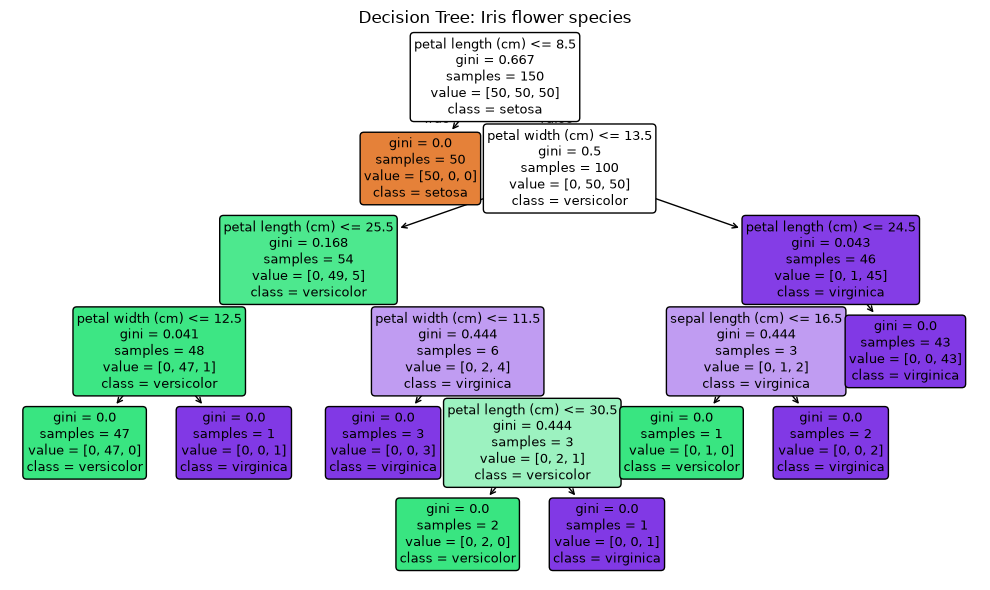

In [11]:
"""
Decision Tree Lab - Starter Code
=================================
Dataset: "Should I play tennis today?" (a classic tiny teaching dataset)
Each row is a PAST DAY with known weather conditions and whether tennis
was played. This is our LABELED training data -> supervised learning.

Fill in the TODOs. Estimated time: 10-12 minutes.
"""

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 1. THE LABELED DATA
# -----------------------------------------------------------------
#data = pd.DataFrame({
   # "outlook":     ["sunny", "sunny", "overcast", "rain", "rain", "rain",
    #                 "overcast", "sunny", "sunny", "rain", "sunny",
   #                  "overcast", "overcast", "rain"],
  #  "temperature": ["hot", "hot", "hot", "mild", "cool", "cool", "cool",
 #                    "mild", "cool", "mild", "mild", "mild", "hot", "mild"],
#    "humidity":    ["high", "high", "high", "high", "normal", "normal",
      #                "high", "normal", "high"],
    #"windy":       [False, True, False, False, False, True, True, False,
   #                  False, False, True, True, False, True],
  #  "play_tennis": ["no", "no", "yes", "yes", "yes", "no", "yes", "no",
 #                    "yes", "yes", "yes", "yes", "yes", "no"],
#})

print("Training data (this is what makes it SUPERVISED learning:")
print("every row has an input AND the correct answer/label):\n")
print(data)

from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
data["species"] = iris.target_names[iris.target]
# -----------------------------------------------------------------
# 2. TODO #1: Separate inputs (features) from the label (target)
# -----------------------------------------------------------------
# The model needs to learn a function: features -> label
# X = the columns the model is allowed to look at
# y = the column it's trying to predict
X = data.drop(columns=["species"])   # TODO: is this right? check it. yes
print(X)
y = data["species"]                  # TODO: is this right? check it. yes
print(y)

# If the model could "see" play_tennis while training it would not be learning anything because it would just answer with the answer it has been shown.
# Decision trees in sklearn need numbers, not text, so we encode.
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# -----------------------------------------------------------------
# 3. TODO #2: Create and train ("fit") the model
# -----------------------------------------------------------------
# .fit(X, y) is the moment "learning" happens: the tree searches for
# the sequence of yes/no questions about X that best predicts y.
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_encoded, y)          # TODO: call fit with the right arguments

# -----------------------------------------------------------------
# 4. Look at what it learned
# -----------------------------------------------------------------
feature_names = list(X.columns)
print("\nLearned decision rules:\n")
print(export_text(clf, feature_names=feature_names))

plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=feature_names, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree: Iris flower species")
plt.tight_layout()
plt.savefig("iris_tree.png", dpi=150)
print("\nSaved a picture of the tree to iris_tree.png")

# -----------------------------------------------------------------
# 5. TODO #3: Predict on a NEW day the model has never seen
# -----------------------------------------------------------------
# This is the payoff of supervised learning: generalizing to new,
# unlabeled examples using the pattern learned from labeled ones.

new_flower = pd.DataFrame({
    "sepal length (cm)": [6],
    "sepal width (cm)": [3],
    "petal length (cm)": [5],
    "petal width (cm)": [2],
})
new_flower_encoded = encoder.transform(new_flower)
prediction = clf.predict(new_flower_encoded)   # TODO: predict on new_flower_encoded

print(f"\nNew flower: {new_flower.to_dict(orient='records')[0]}")
print(f"Prediction: species = {prediction[0]}")
# -----------------------------------------------------------------
# 6. STRETCH GOAL (if time remains)
# -----------------------------------------------------------------
# Try changing max_depth to 1, then to 10. Re-run and compare the
# tree diagrams and the training accuracy. What happens? Why?
# The model is less accurate with a max depth of one on the training data than higher values because it can only ask one question.
# The model starts to memorize the quirks of the specific 14 days rather than learning the general weather pattens when there is a max depth of 10.

# 1. This is supervised learning because the model is trained with data that has the correct answer attached.
# 2. Yes, but it may not be used in the tree if it turned out to be useless for predicting tennis. This is because the model chooses questions that lead to determining the correct answer based on the patterns in the training data.
# 3. A very deep, perfectly accurate tree on the training data may be a worse model than a shallower slightly less accurate one in practice because the very deep one could be overfitting. This means it is so specific to its training examples that it fails to generalize to the new ones it is presented with.
# 4. A real world example that could be modeled as a decision tree is if I go to the library after class. The features would be is it raining, do I have a test this week, did I finish my homework. The label would be go_to_library.
# accuracy = clf.score(X_encoded, y)
# print(f"Training accuracy: {accuracy:.2%}")